In [2]:
#Installing necessary libraries

%pip install control > NUL
%pip install matplotlib > NUL
%pip install numpy > NUL

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import control as ctrl
from math import exp, sqrt, sin
import matplotlib.pyplot as plt
import numpy as np

#Declaration of system constants/parameters

s = ctrl.TransferFunction.s

m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c_val = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

x_2e = 0

Adjust x_1e below in the range (0.47-0.53)

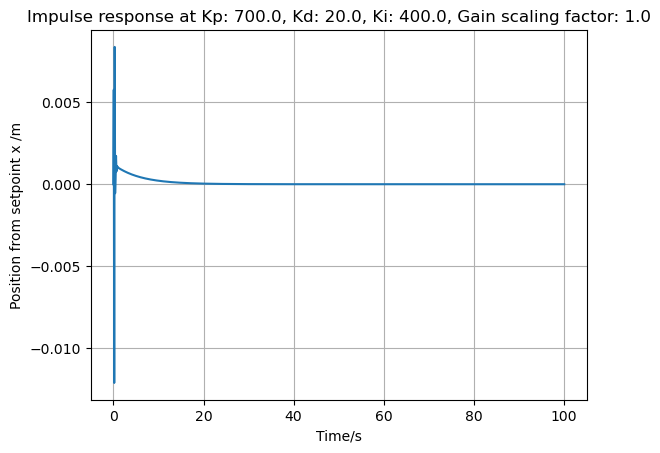

Max: 0.008 m 
Min: -0.012 m
Maximum overshoot: 2.479%


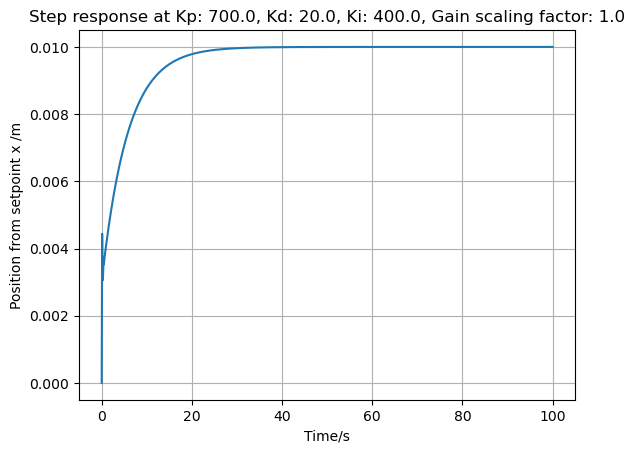

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: -0.000%




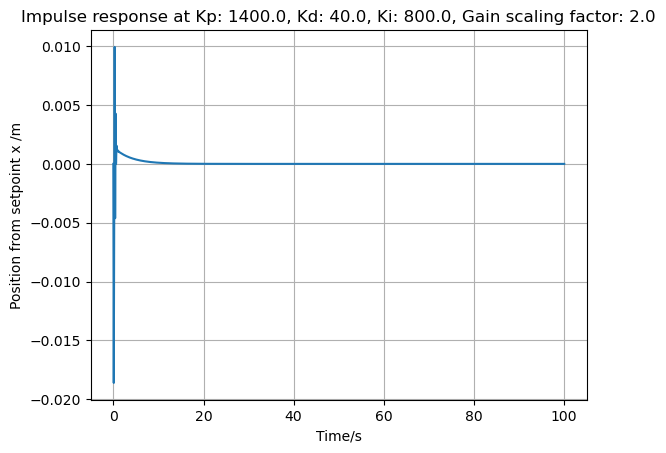

Max: 0.010 m 
Min: -0.019 m
Maximum overshoot: 3.797%


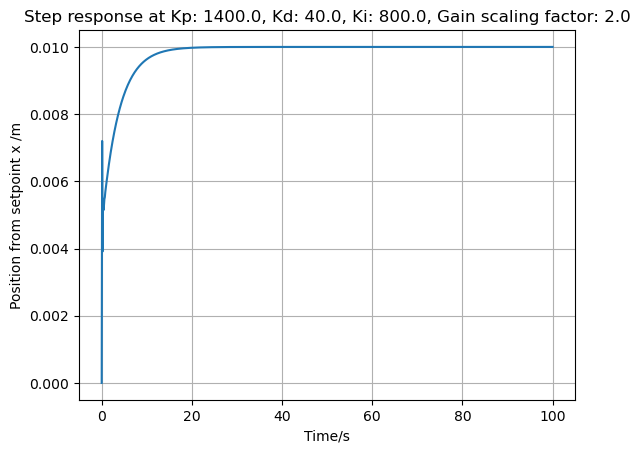

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: -0.000%




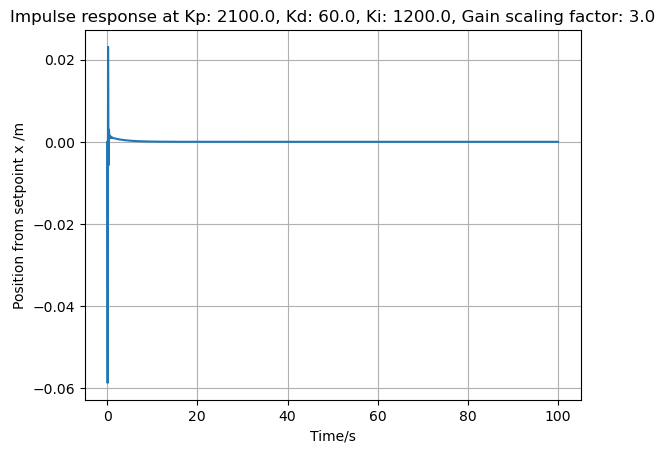

Max: 0.023 m 
Min: -0.059 m
Maximum overshoot: 11.997%


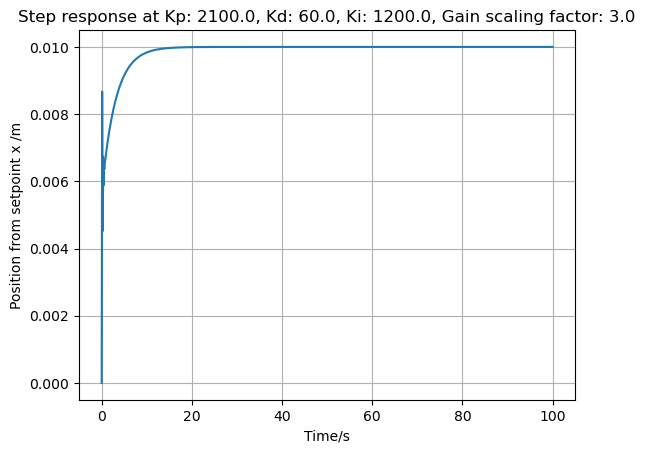

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: 0.000%




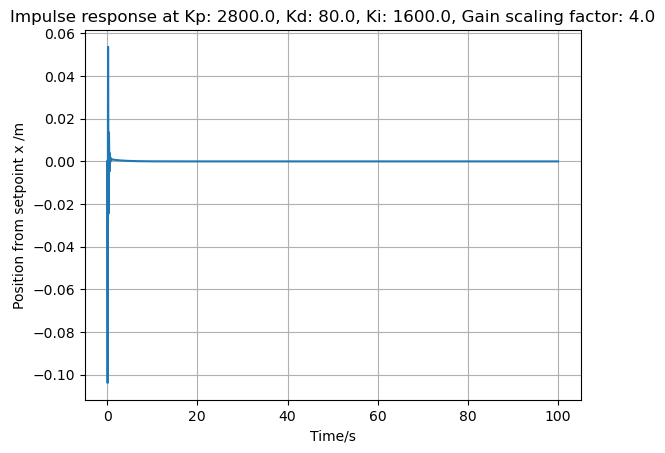

Max: 0.054 m 
Min: -0.104 m
Maximum overshoot: 21.188%


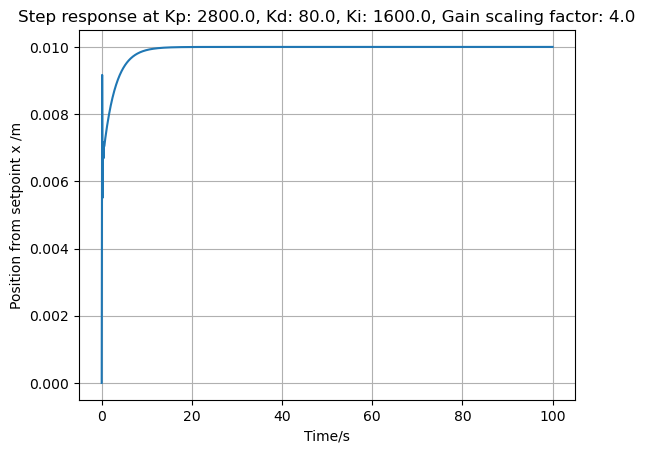

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: 0.000%




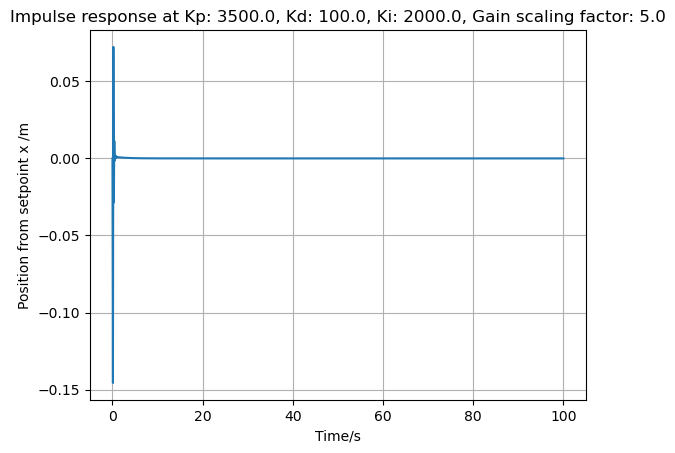

Max: 0.072 m 
Min: -0.146 m
Maximum overshoot: 29.723%


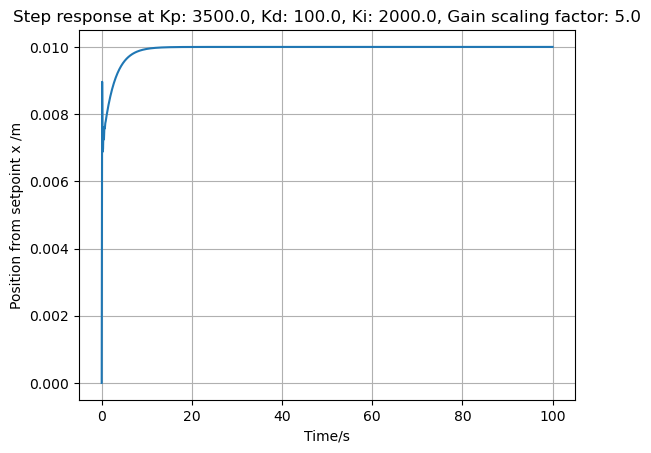

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: -0.000%




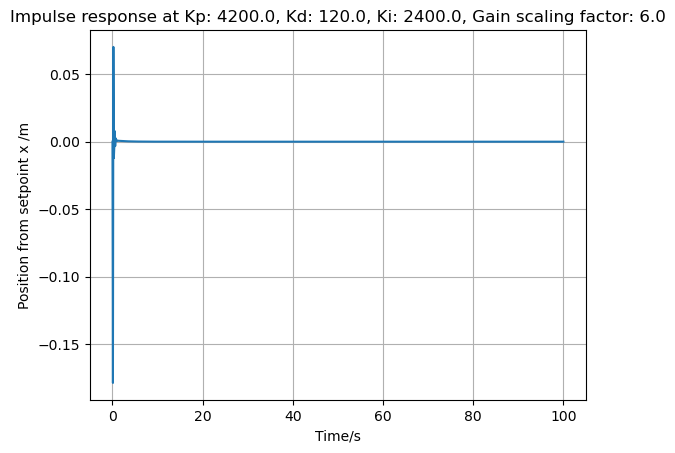

Max: 0.070 m 
Min: -0.179 m
Maximum overshoot: 36.445%


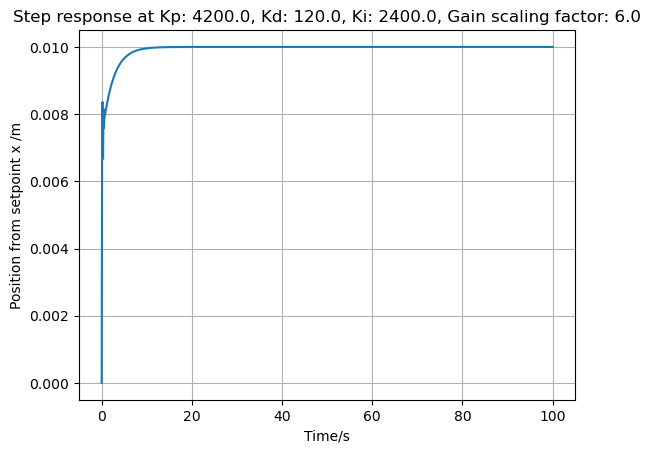

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: 0.000%




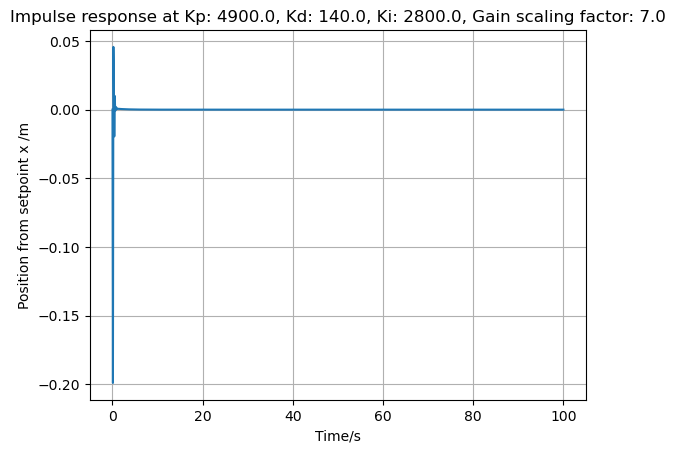

Max: 0.046 m 
Min: -0.199 m
Maximum overshoot: 40.606%


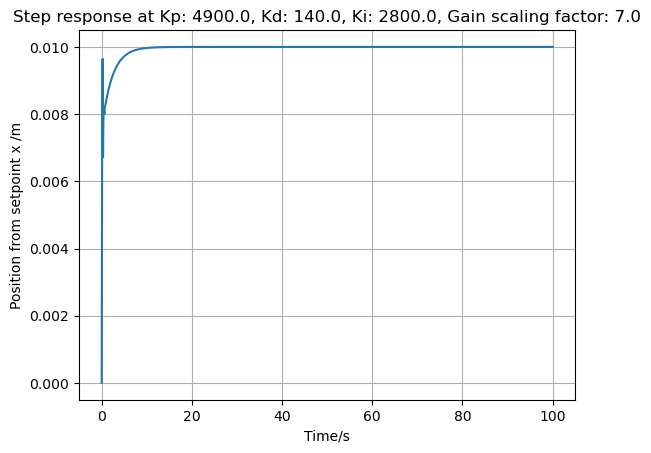

Max: 0.010 m 
Min: 0.000 m
Maximum overshoot: -0.000%




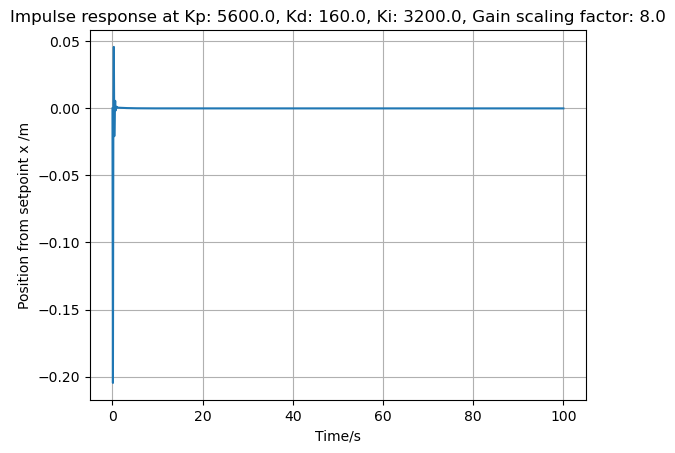

Max: 0.046 m 
Min: -0.205 m
Maximum overshoot: 41.788%


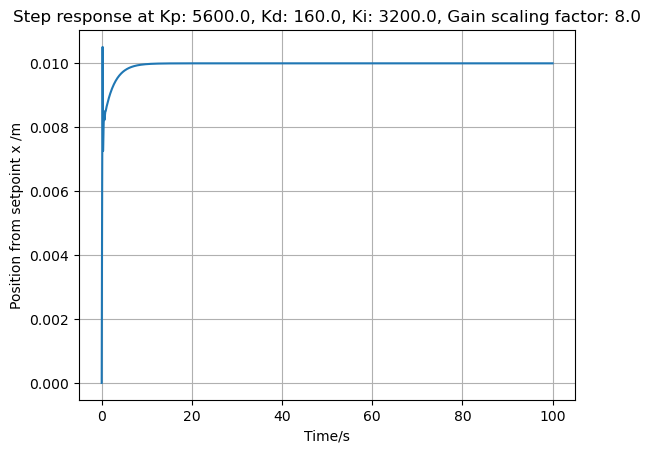

Max: 0.011 m 
Min: 0.000 m
Maximum overshoot: 0.105%




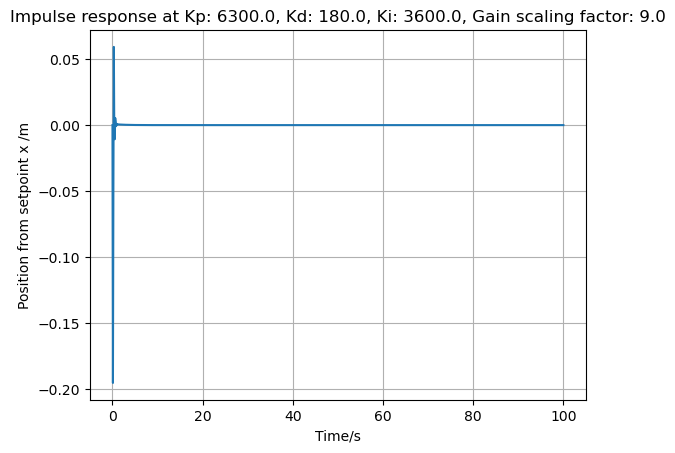

Max: 0.059 m 
Min: -0.195 m
Maximum overshoot: 39.841%


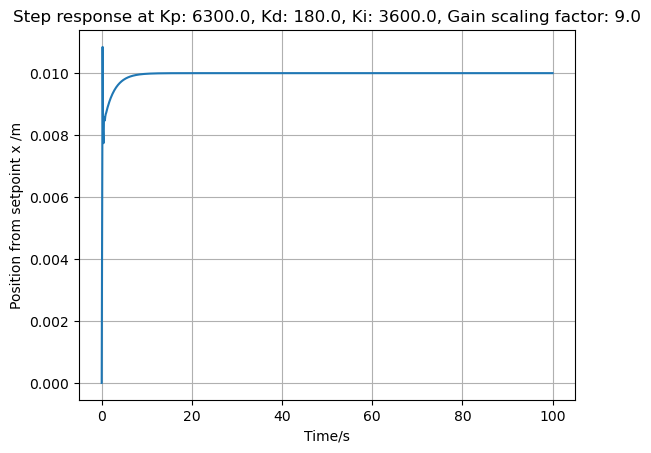

Max: 0.011 m 
Min: 0.000 m
Maximum overshoot: 0.173%




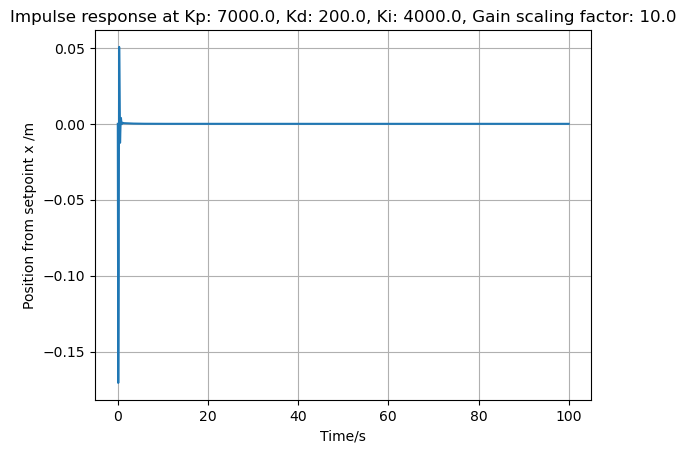

Max: 0.051 m 
Min: -0.171 m
Maximum overshoot: 34.827%


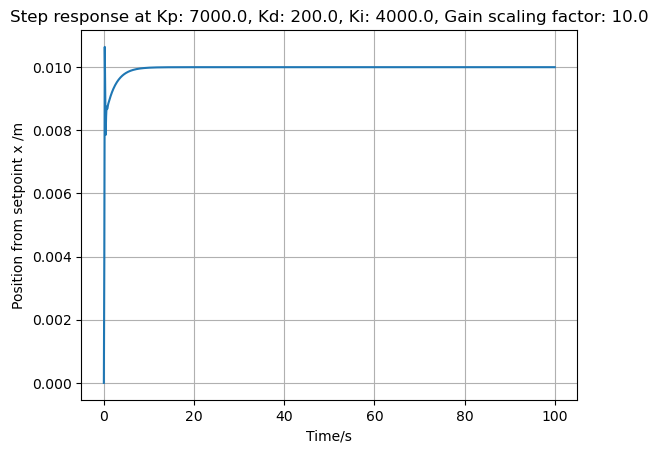

Max: 0.011 m 
Min: 0.000 m
Maximum overshoot: 0.131%




In [7]:
x_1e = 0.49



x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c_val)

a_3 = (5/(7*m)) * (2*c_val*x_3e)/((delta - x_1e)**2) #x3
a_2 = (5/(7*m))*(-b) #x2
a_1 = (5/(7*m)) * ( (2*c_val*(x_3e**2) ) / ( (delta - x_1e)**3 )  -k) #x1

b_1 = 1/ (L0 + L1*exp(-alpha*(delta - x_1e)))
b_2 = -R/ (L0 + L1*exp(-alpha*(delta - x_1e)))

Gm = a_3/(s**2 - a_2*s - a_1)
Ge = b_1/(s - b_2)
Gs = (1)/((tau*s)+1)

Gme = Gm*Ge




Kp = 700
Kd = 20
Ki = 400

timepts = np.linspace(0, 10, 1000)


#Setpoints less than 0.5m have a settling time issue, so the time range is increased to better capture the system response.
if x_1e < 0.5:
  timepts = np.linspace(0, 100, 1000)

for Gain_scaling_factor in [n for n in np.linspace(1,10,10)]:

  Gc = Gain_scaling_factor * (Kp + Ki/s + Kd*s) 
  Gload = ctrl.feedback(Gme*Gc, Gs)

  poles = ctrl.poles(Gload)


  #Only plot the responses if the system is stable (all poles have negative real parts)
  if all(pole.real < 0 for pole in poles):
    
  #Impulse response

    time,xs = ctrl.impulse_response(Gload, timepts=timepts)
    xs_scaled = xs*0.01
    plt.plot(time, xs_scaled)
    plt.title(f"Impulse response at Kp: {Kp * Gain_scaling_factor}, Kd: {Kd * Gain_scaling_factor}, Ki: {Ki * Gain_scaling_factor}, Gain scaling factor: {Gain_scaling_factor}")
    plt.xlabel("Time/s")
    plt.ylabel("Position from setpoint x /m")
    plt.grid() 
    plt.show()

    impulse_response_max_value = max(xs_scaled)
    impulse_response_min_value = min(xs_scaled)
    impulse_response_max_overshoot = abs(impulse_response_min_value )

    print(f"Max: {impulse_response_max_value:.3f} m \nMin: {impulse_response_min_value:.3f} m")
    print(f"Maximum overshoot: {(impulse_response_max_overshoot / x_1e)*100:.3f}%")


    #step response

    time,xs = ctrl.step_response(Gload, timepts=timepts)
    xs_scaled = xs*0.01
    plt.plot(time, xs_scaled)
    plt.title(f"Step response at Kp: {Kp * Gain_scaling_factor}, Kd: {Kd * Gain_scaling_factor}, Ki: {Ki * Gain_scaling_factor}, Gain scaling factor: {Gain_scaling_factor}")
    plt.xlabel("Time/s")
    plt.ylabel("Position from setpoint x /m")
    plt.grid()
    plt.show()

    step_response_max_value = max(xs_scaled)
    step_response_min_value = min(xs_scaled)
    step_response_max_overshoot = max( abs(step_response_max_value) , abs(step_response_min_value) )

    print(f"Max: {step_response_max_value:.3f} m \nMin: {step_response_min_value:.3f} m")
    print(f"Maximum overshoot: {((step_response_max_overshoot -0.01) / x_1e)*100:.3f}%\n\n")




Optimal gain scaling factors found per setpoint (balance between settling time and overshoot) :


0.47 m: 7

0.48 m: 3

0.49 m : 3

0.51 m = 6,

0.52 m = 10,

0.53 m = 8.

Overshoot is preferably < 20%, however for setpoints > 0.5m, this may not be possible with global gain scaling.

Note that all of these gain scaling value choices are subjectively interpreted.

The specific gains $K_p$, $K_d$, $K_i$ may be adjusted individually in a similar fashion to finding the parameters for the controller at setpoint 0.5m to more effectively tune the controller for each setpoint, however this is both time-consuming and tedious to carry out. Gain scheduling with global gain scaling is found to be more crude and ineffective but simpler to implement.
